In [85]:
# -*- coding: utf-8 -*-
import os
import sys
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib
import matplotlib as mpl
from shapely.geometry import Polygon, MultiPolygon
from shapely.geometry import LineString, Point, box
from shapely.ops import split, unary_union
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
from matplotlib.patches import Wedge, Patch, Circle
from matplotlib.colors import Normalize
from matplotlib import cm
from matplotlib.cm import ScalarMappable
from matplotlib.patches import FancyArrowPatch
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.patches import Circle
from matplotlib.offsetbox import AnchoredOffsetbox, VPacker, HPacker, TextArea, DrawingArea
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg
import matplotlib as mpl
import geopandas as gpd
mpl.rcParams['mathtext.default'] = 'regular'
import matplotlib.image as mpimg


In [86]:
# 中文到英文映射
ch_en_map = {
    "北京市": "Beijing", "天津市": "Tianjin", "上海市": "Shanghai", "重庆市": "Chongqing",
    "河北省": "Hebei", "山西省": "Shanxi", "内蒙古自治区": "Inner Mongolia", "辽宁省": "Liaoning",
    "吉林省": "Jilin", "黑龙江省": "Heilongjiang", "江苏省": "Jiangsu", "浙江省": "Zhejiang",
    "安徽省": "Anhui", "福建省": "Fujian", "江西省": "Jiangxi", "山东省": "Shandong",
    "河南省": "Henan", "湖北省": "Hubei", "湖南省": "Hunan", "广东省": "Guangdong",
    "广西壮族自治区": "Guangxi", "海南省": "Hainan", "四川省": "Sichuan", "贵州省": "Guizhou",
    "云南省": "Yunnan", "西藏自治区": "Tibet", "陕西省": "Shaanxi", "甘肃省": "Gansu",
    "青海省": "Qinghai", "宁夏回族自治区": "Ningxia", "新疆维吾尔自治区": "Sinkiang",
    "台湾省": "Taiwan", "香港特别行政区": "Hong Kong", "澳门特别行政区": "Macau"
}

In [87]:
# ======================================== 0. 控制台 UTF-8 & 中文字体 =====================================
if os.name == 'nt':
    os.system('chcp 65001 >nul')
    if hasattr(sys.stdout, "reconfigure"):
        sys.stdout.reconfigure(encoding='utf-8')

matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial', 'SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False

# —— 1. 路径设定 ——  
prov_shp = r"D:\Research\China_E_C\Map\CN_Map\CN_Province.shp"
city_shp = r"D:\Research\China_E_C\Map\CN_Map_WGS1984\CN_Prefecture.shp"
nine_shp = r"D:\Research\China_E_C\Map\CN_Map\Jiu_Duan_Xian.shp"

out_dir = r"D:\Research\China_E_C\Paper_Fig\Fig_4cases\EC_Network\CN50"
os.makedirs(out_dir, exist_ok=True)

In [88]:
#============================== 2. 读取 & 投影 ===============================  
provinces = gpd.read_file(city_shp)

prov = gpd.read_file(prov_shp, encoding='utf-8')
nine = gpd.read_file(nine_shp, encoding='utf-8')

# 2.1 用于切分的地理 CRS
prov_geo = prov.to_crs(epsg=4326)

# 2.2 投影到 EPSG:2343，用于最终绘图
prov_2343 = prov.to_crs(epsg=2343)
nine_2343 = nine.to_crs(epsg=2343)

# 2.3 剔除小岛
def remove_small_islands(geom, min_area=5e9):
    if isinstance(geom, MultiPolygon):
        parts = [p for p in geom.geoms if p.area > min_area]
        if not parts:
            return geom
        return parts[0] if len(parts)==1 else MultiPolygon(parts)
    return geom if geom.area > min_area else geom

prov_2343["geometry"] = prov_2343["geometry"].apply(lambda g: remove_small_islands(g, min_area=5e9))


[-2244505.40452648  2012980.3232581   2720859.35887738  6098749.96582366]


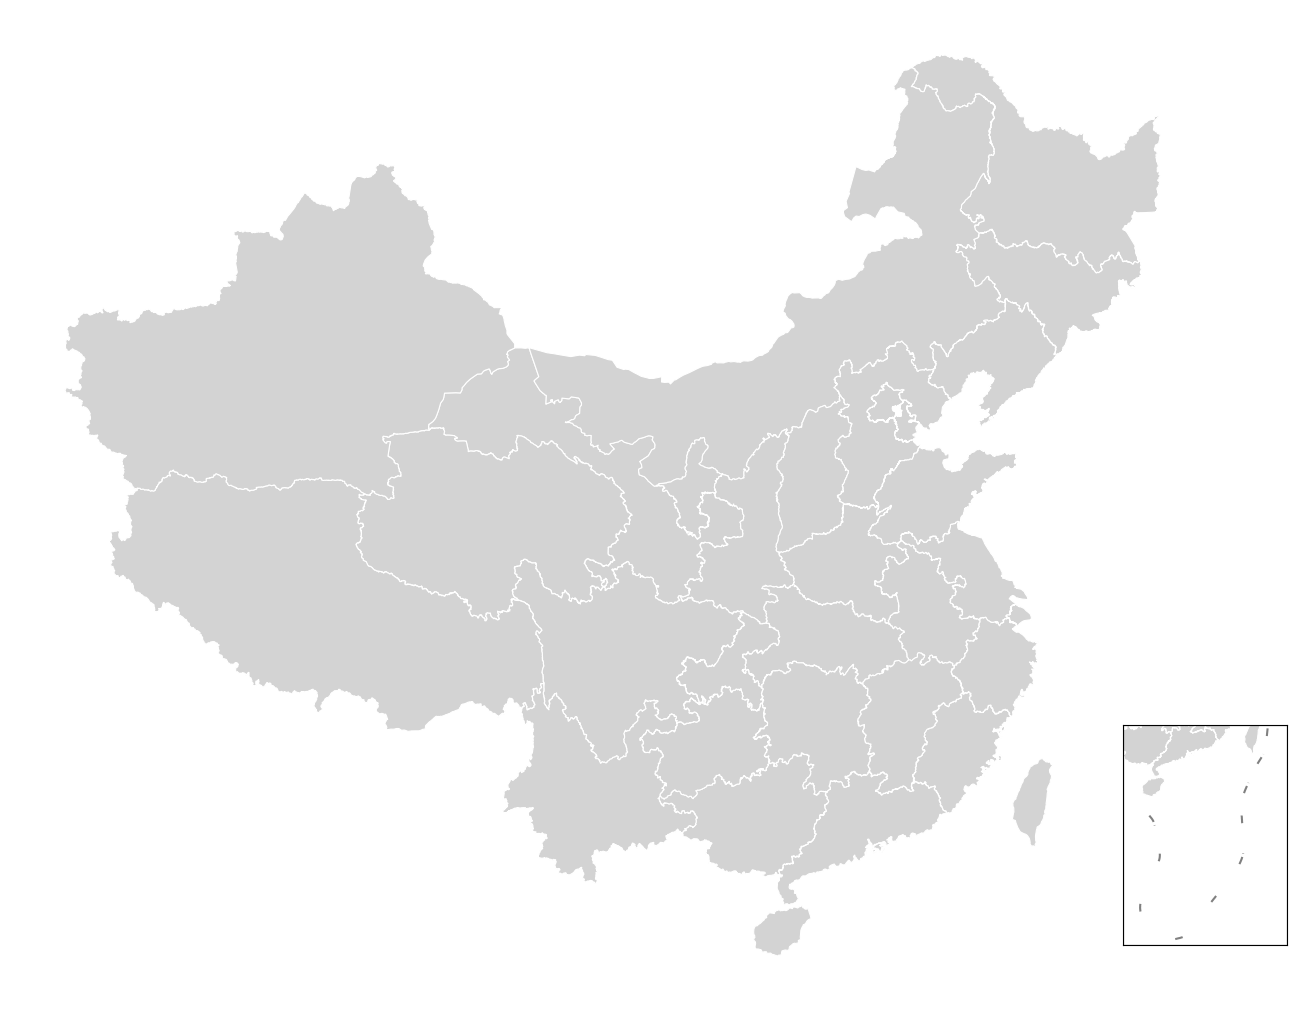

In [89]:
# ============================ 3. 绘制主图 + 九段线 inset ==============================  
fig, ax = plt.subplots(figsize=(16,10),constrained_layout=True)
print(prov_2343.total_bounds)
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
FigureCanvas(fig)
fig.canvas.draw()
albers_proj = 'EPSG:2343'
# 3.1 主图：省界背景
prov_2343.plot(ax=ax, facecolor="lightgrey", edgecolor='white', linewidth=0.8, zorder=1)

#nine_2343.plot(ax=ax, color='gray',  linewidth=1.5,  zorder=2)
ax.set_axis_off()
# 3.2 九段线 inset（保持和之前一致）
# 地理 CRS 下裁剪框
bbox_geo = box(106.5, 2.8, 123.0, 24.5)
# 投影裁剪框
bbox_2343 = gpd.GeoSeries([bbox_geo], crs=4326).to_crs(epsg=2343).iloc[0]
# 裁剪图层
prov_crop = prov_2343[prov_2343.intersects(bbox_2343)]
nine_crop = nine_2343[nine_2343.intersects(bbox_2343)]
axins = fig.add_axes([0.78, 0.06, 0.18, 0.22])

#axins = inset_axes(ax, width='20%', height='20%', loc='lower right', bbox_to_anchor=(0.11, 0.27, 1.0, 1.0), bbox_transform=ax.transAxes, borderpad=0)
prov_crop.plot(ax=axins, facecolor="lightgrey", edgecolor='white', linewidth=0.8, zorder=1)
nine_crop.plot(ax=axins, color='gray', linewidth=1.5, linestyle='--', zorder=2)

# 固定 inset 范围
minx, miny, maxx, maxy = bbox_2343.bounds
axins.set_xlim(minx, maxx)
axins.set_ylim(miny, maxy)
axins.set_xticks([])
axins.set_yticks([])

rect = Rectangle((0, 0), 1, 1, transform=axins.transAxes, fill=False, edgecolor='black', linewidth=0.8)

axins.add_patch(rect)
ax.axis('off')


def remove_small_islands(geom, min_area=5e9):
    """
    过滤掉面积小于 min_area 的小岛。
    geom: Polygon 或 MultiPolygon
    """
    if isinstance(geom, MultiPolygon):
        parts = [p for p in geom.geoms if p.area > min_area]
        if not parts:
            return geom
        return parts[0] if len(parts)==1 else MultiPolygon(parts)
    # 单面片
    return geom if geom.area > min_area else geom



        

In [90]:
# ============================== 4. 基于地级市将内蒙古分为蒙西／蒙东两块 =================================

# 4.1 读取并投影地级市 shp（CN_Prefecture.shp）
city = gpd.read_file(city_shp, encoding='utf-8').to_crs(epsg=2343)

# 4.2 筛选“内蒙古自治区”下属所有地级市
im_city = city[city['省']=="内蒙古自治区"].copy()

# 4.3 定义蒙西／蒙东的地市名单
east_list = ["赤峰市","通辽市","兴安盟","呼伦贝尔市"]

west_list = [c for c in im_city['市'].unique() if c not in east_list]

# 4.4 新增 region 列，然后 dissolve 合并
im_city['region'] = im_city['市'].apply(
    lambda s: 'W_InnerMongo' if s in west_list
              else ('E_InnerMongo' if s in east_list else None)
)

im_west = (
    im_city[im_city['region']=="W_InnerMongo"]
    .dissolve(by='region')
    .reset_index()   # 把 region 提升为一列
)

im_east = (
    im_city[im_city['region']=="E_InnerMongo"]
    .dissolve(by='region')
    .reset_index()
)

In [91]:
# ============================== 5. 绘制电网区域边框 ==============================
prov_2343['province_cn'] = prov_2343['省']
def remove_small_islands(geom, min_area=5e9):
    """
    过滤掉面积小于 min_area 的小岛。
    geom: Polygon 或 MultiPolygon
    """
    if isinstance(geom, MultiPolygon):
        parts = [p for p in geom.geoms if p.area > min_area]
        if not parts:
            return geom
        return parts[0] if len(parts)==1 else MultiPolygon(parts)
    # 单面片
    return geom if geom.area > min_area else geom

# —— 4.5 定义电网区域及样式 ——  
grid_regions = {
    'NE': { 'province_cn': ["辽宁省","吉林省","黑龙江省"],
            'use_im_east': True,
            'style': dict(edgecolor="#4e79a7", linewidth=2, linestyle='--') },

    'NC': { 'province_cn': ["山东省","山西省","河北省","天津市","北京市"],
            'use_im_west': True,
            'style': dict(edgecolor="#2a4651", linewidth=2, linestyle='--') },

    'EC': { 'province_cn': ["上海市","江苏省","浙江省","安徽省","福建省"],
            'style': dict(edgecolor="#5e8440", linewidth=2, linestyle='--') },

    'HC': { 'province_cn': ["湖南省","湖北省","江西省","河南省"],
            'style': dict(edgecolor="#c7a76c", linewidth=2, linestyle='--') },

    'SW': { 'province_cn': ["四川省","重庆市","西藏自治区"],
            'style': dict(edgecolor="#841e2a", linewidth=2, linestyle='--') },

    'NW': { 'province_cn': ["陕西省","甘肃省","宁夏回族自治区","青海省","新疆维吾尔自治区"],
            'style': dict(edgecolor="#c55274", linewidth=2, linestyle='--') },

    'SC': { 'province_cn': ["广东省","广西壮族自治区","海南省","云南省","贵州省"],
            'style': dict(edgecolor="#347219", linewidth=2, linestyle='--') }
}

# 构造每个区域的合并几何并带上样式
grid_borders = []
for code, info in grid_regions.items():
    # 取普通省份的 geometry
    geoms = prov_2343[prov_2343['province_cn'].isin(info['province_cn'])].geometry.tolist()
    # 加蒙东/蒙西
    if info.get('use_im_east'):
        geoms.append(im_east.geometry.iloc[0])
    if info.get('use_im_west'):
        geoms.append(im_west.geometry.iloc[0])
    # 合并并过滤小岛
    merged = unary_union(geoms)
    merged = remove_small_islands(merged, min_area=5e9)
    # 一次性 append region, geometry, style
    grid_borders.append({
        'region': code,
        'geometry': merged,
        'style': info['style']
    })

grid_gdf = gpd.GeoDataFrame(grid_borders, crs=prov_2343.crs)

# 按区域分别绘制
for _, row in grid_gdf.iterrows():
    gpd.GeoSeries(row.geometry).boundary.plot(
        ax=ax, zorder=3, **row['style']
    )

legend_handles = []
for code, info in grid_regions.items():
    style = info['style']
    # 用 Line2D 构造一个仅用于图例的线条示例
    line = Line2D(
        [0], [0],
        color=style['edgecolor'],
        linewidth=style['linewidth'],
        linestyle=style['linestyle']
    )
    legend_handles.append((line, code))

# 拆解 handles, labels
handles, labels = zip(*legend_handles)

# 在图上添加图例
# ============================== Province Region 图例 ==============================

# 单独控制图例位置
REGION_LEGEND_X = -0.18
REGION_LEGEND_Y = 0.26

leg_region = ax.legend(
    handles,
    labels,
    title="Province Region",
    loc="lower left",
    bbox_to_anchor=(
        REGION_LEGEND_X,
        REGION_LEGEND_Y
    ),
    bbox_transform=ax.transAxes,

    frameon=False,
    edgecolor="gray",
    ncol=2,

    # 字体可参考电网图
    fontsize=15.8,
    title_fontsize=18.6,

    columnspacing=1.5,
    labelspacing=0.7
)

leg_region.get_title().set_fontweight("bold")

# 图例不参与布局计算，避免改变地图位置和大小
leg_region.set_in_layout(False)

# 必须保留，否则后续创建其他图例时会被替换
ax.add_artist(leg_region)


<Figure size 640x480 with 0 Axes>

In [92]:
# ============================ 6. CO2 Storage Capacity ==============================  
# 数据来源：Stage_3_fig_gdp.xlsx -> CS_Prov_50；省份简称映射：Prov_contrast.xlsx
stage3_fig_path = r"D:\Research\China_E_C\Paper_Fig\Fig_4cases\EC_Network\CN50\Stage_3_fig.xlsx"
prov_contrast_path = r"D:\Research\China_E_C\Map\CN_Map_WGS1984\Prov_contrast.xlsx"

# 1. 读取省级封存量：第1列为省份简称，第2列为封存量，单位 Mt
df_cs = pd.read_excel(
    stage3_fig_path,
    sheet_name="CS_Prov_50",
    header=None,
    names=["Prov_short", "Value"]
)
df_cs["Prov_short"] = df_cs["Prov_short"].astype(str).str.strip()
df_cs["Value"] = pd.to_numeric(df_cs["Value"], errors="coerce").fillna(0)

# 2. 读取省份简称—英文全称对照表
prov_contrast = pd.read_excel(prov_contrast_path)
prov_contrast["Prov_short"] = prov_contrast["Prov_short"].astype(str).str.strip()
prov_contrast["Prov_name"] = prov_contrast["Prov_name"].astype(str).str.strip()

df_co2 = (
    df_cs
    .merge(prov_contrast[["Prov_name", "Prov_short"]], on="Prov_short", how="left")
    .rename(columns={"Prov_name": "province_en"})
)

# 检查是否存在没有匹配到英文省名的简称
unmatched = df_co2.loc[df_co2["province_en"].isna(), "Prov_short"].unique()
if len(unmatched) > 0:
    print("以下省份简称未在 Prov_contrast.xlsx 中匹配到，请检查：", unmatched)

# 3. 中文省名转英文省名，用于和 CS_Prov_50 合并
ch_en_df = pd.DataFrame(list(ch_en_map.items()), columns=["province_cn", "province_en"])
prov_2343["province_cn"] = prov_2343["省"]

# 4. 普通省份图层：剔除整块内蒙古，后续用蒙西/蒙东替代
prov_base = (
    prov_2343
    .merge(ch_en_df, on="province_cn", how="left")
)

mask_drop_im = prov_base["province_cn"].eq("内蒙古自治区")
prov_main = prov_base.loc[~mask_drop_im, ["province_cn", "province_en", "geometry"]].copy()

# 5. 蒙西、蒙东图层。名称需与 Prov_contrast.xlsx 中的 Prov_name 保持一致
west_df = gpd.GeoDataFrame(
    {"province_cn": ["蒙西"], "province_en": ["W_InnerMongolia"]},
    geometry=im_west.geometry,
    crs=prov_2343.crs
)

east_df = gpd.GeoDataFrame(
    {"province_cn": ["蒙东"], "province_en": ["E_InnerMongolia"]},
    geometry=im_east.geometry,
    crs=prov_2343.crs
)

# 6. 合并普通省份 + 蒙西/蒙东，再合并封存量
plot_gdf = pd.concat([prov_main, west_df, east_df], ignore_index=True)
plot_gdf = gpd.GeoDataFrame(plot_gdf, geometry="geometry", crs=prov_2343.crs)

plot_gdf = (
    plot_gdf
    .merge(df_co2[["province_en", "Value"]], on="province_en", how="left")
)

# CS_Prov_50 中没有出现的省份按 0 Mt 处理，避免地图出现空白
# plot_gdf["Value"] = plot_gdf["Value"].fillna(0)

# 7. 可视化参数：单位 Mt
vmin = 0
vmax = np.ceil(plot_gdf["Value"].max() / 500) * 500
if vmax <= 0:
    vmax = 1

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

orig_cmap = mpl.colormaps["plasma_r"]
colors = orig_cmap(np.linspace(0, 1, 256))
colors[:, -1] = 0.40
cmap_alpha = mpl.colors.ListedColormap(colors)

# 8. 绘制省份封存量底色
plot_gdf.plot(
    column="Value",
    cmap=cmap_alpha,
    norm=norm,
    linewidth=0.5,
    edgecolor="white",
    ax=ax,
    zorder=1,
)

# 9. 添加 colorbar
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_alpha)
sm._A = []

# 清理重复运行该单元格时残留的旧 colorbar axes。
# 本 Notebook 中除主地图 ax 和南海插图 axins 外，
# 其余 axes 都视为旧 colorbar 并删除。
for _extra_ax in list(fig.axes):
    if _extra_ax is not ax and _extra_ax is not axins:
        _extra_ax.remove()

# 不再使用 inset_axes。
# 直接根据主地图 axes 的最终位置创建独立 colorbar axes。
fig.canvas.draw()

_ax_pos_for_cbar = ax.get_position().frozen()

# ============================== Colorbar controls ==============================

# colorbar 与主地图之间的水平距离
CBAR_GAP = 0.001

# colorbar 宽度，使用 Figure 坐标
CBAR_WIDTH = 0.022

# colorbar 长度占主地图高度的比例
CBAR_HEIGHT_RATIO = 0.52

_cbar_height = (
    _ax_pos_for_cbar.height
    * CBAR_HEIGHT_RATIO
)

# 让加长后的 colorbar 保持竖直居中
_cbar_bottom = (
    _ax_pos_for_cbar.y0
    + (_ax_pos_for_cbar.height - _cbar_height) / 2
    + 0.12
)

_cbar_left = (
    _ax_pos_for_cbar.x1
    + CBAR_GAP
)

cax = fig.add_axes([
    _cbar_left,
    _cbar_bottom,
    CBAR_WIDTH,
    _cbar_height,
])

cbar = plt.colorbar(
    sm,
    cax=cax,
    orientation="vertical"
)

cbar.ax.patch.set_facecolor("lightgrey")
cbar.outline.set_edgecolor("none")

cbar.ax.tick_params(
    axis="y",
    which="major",
    direction="in",
    labelsize=16,
    length=3.0,
    width=1.2,
)

cbar.set_label(
    "CO$_2$ Storage Capacity (Mt)",
    fontsize=22,
    labelpad=10,
)

# ============================== 固定地图、南海插图和 colorbar ==============================

# 先让当前布局完成一次正式计算
fig.canvas.draw()

# 保存主地图位置和显示范围
main_ax_position = ax.get_position().frozen()
main_xlim = ax.get_xlim()
main_ylim = ax.get_ylim()

# 保存南海插图位置
inset_ax_position = axins.get_position().frozen()

# 保存 colorbar 位置
colorbar_ax_position = cax.get_position().frozen()

# 关闭 constrained layout，避免后续图例重新调整地图
try:
    fig.set_layout_engine(None)
except (AttributeError, TypeError):
    fig.set_constrained_layout(False)

# 恢复并固定三个 axes
ax.set_position(main_ax_position)
axins.set_position(inset_ax_position)
cax.set_position(colorbar_ax_position)

# 固定地图显示范围
ax.set_xlim(main_xlim)
ax.set_ylim(main_ylim)

# 后续绘制连线、节点和饼图时不允许自动改变地图范围
ax.set_autoscale_on(False)
axins.set_autoscale_on(False)
cax.set_autoscale_on(False)

print("CS_Prov_50 省级封存量绘制完成，单位：Mt")
print("最大封存量：", plot_gdf["Value"].max(), "Mt")





CS_Prov_50 省级封存量绘制完成，单位：Mt
最大封存量： 2486.54036211693 Mt


<Figure size 640x480 with 0 Axes>

In [93]:
# ============================ 7. Provincal CO2 Transmission Line ============================== 
# 数据来源：Stage3_fig.xlsx -> U_Prv_acm_50；省份简称映射：Prov_contrast.xlsx；省份中心点：Province_Centroids.xlsx
province_centroids_path = r"D:\Research\China_E_C\Map\CN_Map_WGS1984\Province_Centroids.xlsx"

# 1. 读取省际碳传输容量（单位：Mt/yr）
df_line = pd.read_excel(
    stage3_fig_path,
    sheet_name="U_Prv_acm_50",
    header=None,
    names=["Origin", "Destination", "Cap"]
)
df_line["Origin"] = df_line["Origin"].astype(str).str.strip()
df_line["Destination"] = df_line["Destination"].astype(str).str.strip()
df_line["Cap"] = pd.to_numeric(df_line["Cap"], errors="coerce")
df_line = df_line.dropna(subset=["Origin", "Destination", "Cap"]).copy()
df_line = df_line[df_line["Cap"] > 0].copy()

# 2. 读取简称映射与省份中心点坐标
prov_contrast = pd.read_excel(prov_contrast_path)
prov_contrast["Prov_short"] = prov_contrast["Prov_short"].astype(str).str.strip()
prov_contrast["Prov_name"] = prov_contrast["Prov_name"].astype(str).str.strip()

df_cent = pd.read_excel(province_centroids_path)
df_cent = df_cent.rename(columns={"Prons": "Prov_short", "Lons": "Lon", "Lats": "Lat"})
df_cent["Prov_short"] = df_cent["Prov_short"].astype(str).str.strip()
df_cent["Lon"] = pd.to_numeric(df_cent["Lon"], errors="coerce")
df_cent["Lat"] = pd.to_numeric(df_cent["Lat"], errors="coerce")
df_cent = df_cent.dropna(subset=["Prov_short", "Lon", "Lat"]).copy()

df_cent = df_cent.merge(prov_contrast[["Prov_short", "Prov_name"]], on="Prov_short", how="left")

# 3. 完整性检查
used_codes = sorted(set(df_line["Origin"]).union(set(df_line["Destination"])))
missing_in_centroids = sorted(set(used_codes) - set(df_cent["Prov_short"]))
missing_in_contrast = sorted(set(used_codes) - set(prov_contrast["Prov_short"]))

if missing_in_centroids:
    print("以下省份简称未在 Province_Centroids.xlsx 中找到：", missing_in_centroids)
if missing_in_contrast:
    print("以下省份简称未在 Prov_contrast.xlsx 中找到：", missing_in_contrast)

# 4. 省份中心点：WGS84 -> EPSG:2343（与主图一致）
cent_gdf = gpd.GeoDataFrame(
    df_cent,
    geometry=gpd.points_from_xy(df_cent["Lon"], df_cent["Lat"]),
    crs="EPSG:4326"
).to_crs(epsg=2343)

centroid_dict = dict(zip(cent_gdf["Prov_short"], cent_gdf.geometry))

# 5. 线宽分段（单位：Mt/yr）
# 如需调整分段，只需修改下面三个列表
cap_bins = [0, 20, 40, 70, 130]
cap_labels = [
    r"$0 < U_{i,j}^{Prov} \leq 20$",
    r"$20 < U_{i,j}^{Prov} \leq 40$",
    r"$40 < U_{i,j}^{Prov} \leq 70$",
    r"$70 < U_{i,j}^{Prov} \leq 130$"
]
cap_widths = [1, 2, 3, 4]

def get_width_by_cap(val, bins=cap_bins, widths=cap_widths):
    for upper, lw in zip(bins[1:], widths):
        if val <= upper:
            return lw
    return widths[-1]

# 6. 绘制省际传输线
line_color = "#c02bb8"   # 省际线颜色（紫红色）
node_face = "#f58709"    # 省份中心点颜色
node_edge = "black"

# 先画细线、后画粗线，保证粗线不被遮挡
for _, row in df_line.sort_values("Cap", ascending=True).iterrows():
    o = row["Origin"]
    d = row["Destination"]
    cap = row["Cap"]

    if o not in centroid_dict or d not in centroid_dict:
        print(f"[Skip] 缺少中心点坐标：{o} -> {d}")
        continue

    p_o = centroid_dict[o]
    p_d = centroid_dict[d]
    lw = get_width_by_cap(cap)

    ax.plot(
        [p_o.x, p_d.x], [p_o.y, p_d.y],
        color=line_color,
        linestyle='-',
        linewidth=lw,
        alpha=0.82,
        zorder=4
    )

# 7. 绘制参与省际传输的省级中心点
used_cent = cent_gdf[cent_gdf["Prov_short"].isin(used_codes)].copy()
ax.scatter(
    used_cent.geometry.x,
    used_cent.geometry.y,
    s=50,
    facecolor=node_face,
    edgecolor=node_edge,
    linewidth=0.4,
    zorder=5
)

# 8. 添加图例（分段线宽）
legend_handles = []
legend_labels = []

for lbl, lw in zip(cap_labels, cap_widths):
    legend_handles.append(
        Line2D([0, 1], [0, 0], color=line_color, linestyle='-', linewidth=lw)
    )
    legend_labels.append(lbl)

# ============================== Provincial CO2 Transport 图例 ==============================

PROV_LEGEND_X = -0.18
PROV_LEGEND_Y = 0.1

leg_prov = ax.legend(
    handles=legend_handles,
    labels=legend_labels,
    title="Provincial CO$_2$ Transport Capacity (Mt/yr)",
    loc="lower left",
    bbox_to_anchor=(
        PROV_LEGEND_X,
        PROV_LEGEND_Y
    ),
    bbox_transform=ax.transAxes,

    frameon=False,
    ncol=2,
    handlelength=3.2,
    columnspacing=1.5,
    labelspacing=0.53,

    # 参考电网络图例字体
    fontsize=15.8,
    title_fontsize=18.5
)

leg_prov.get_title().set_fontweight("bold")
leg_prov.set_in_layout(False)
ax.add_artist(leg_prov)

print("U_Prv_acm_50 省际传输线绘制完成，单位：Mt/yr")
print("省际传输边数：", len(df_line))
print("最大容量：", round(df_line['Cap'].max(), 3), "Mt/yr")


U_Prv_acm_50 省际传输线绘制完成，单位：Mt/yr
省际传输边数： 42
最大容量： 153.95 Mt/yr


In [94]:
# ============================== 8. Intra-provincial CO2 transport (F_imp_50 / F_exp_50) ==============================
# 数据来源：Stage3_fig.xlsx -> F_imp_50 / F_exp_50；地级市中心点：Prefecture_Centroids.xlsx
prefecture_centroids_path = r"D:\Research\China_E_C\Map\CN_Map_WGS1984\Prefecture_Centroids.xlsx"

# 1. 读取省内汇入 / 分配流量（单位：Mt/yr）
df_imp = pd.read_excel(
    stage3_fig_path,
    sheet_name="F_imp_50",
    header=None,
    names=["Prov_short", "Prefecture", "Flow"]
)
df_exp = pd.read_excel(
    stage3_fig_path,
    sheet_name="F_exp_50",
    header=None,
    names=["Prov_short", "Prefecture", "Flow"]
)

for df_ in [df_imp, df_exp]:
    df_["Prov_short"] = df_["Prov_short"].astype(str).str.strip()
    df_["Prefecture"] = df_["Prefecture"].astype(str).str.strip()
    df_["Flow"] = pd.to_numeric(df_["Flow"], errors="coerce")

df_imp = df_imp.dropna(subset=["Prov_short", "Prefecture", "Flow"])
df_exp = df_exp.dropna(subset=["Prov_short", "Prefecture", "Flow"])
df_imp = df_imp[df_imp["Flow"] > 0].copy()
df_exp = df_exp[df_exp["Flow"] > 0].copy()

# 2. 读取地级市中心点经纬度
city_cent = pd.read_excel(prefecture_centroids_path)
city_cent = city_cent.rename(columns={
    "Prons": "Prov_short",
    "Prefx": "Prefecture",
    "Lons": "Lon",
    "Lats": "Lat"
})
city_cent["Prov_short"] = city_cent["Prov_short"].astype(str).str.strip()
city_cent["Prefecture"] = city_cent["Prefecture"].astype(str).str.strip()
city_cent["Lon"] = pd.to_numeric(city_cent["Lon"], errors="coerce")
city_cent["Lat"] = pd.to_numeric(city_cent["Lat"], errors="coerce")
city_cent = city_cent.dropna(subset=["Prov_short", "Prefecture", "Lon", "Lat"]).copy()

# 3. 完整性检查
city_key_all = set(zip(city_cent["Prov_short"], city_cent["Prefecture"]))
imp_missing = sorted(set(zip(df_imp["Prov_short"], df_imp["Prefecture"])) - city_key_all)
exp_missing = sorted(set(zip(df_exp["Prov_short"], df_exp["Prefecture"])) - city_key_all)

if imp_missing:
    print("以下 F_imp_50 地级市未在 Prefecture_Centroids.xlsx 中找到：", imp_missing[:20], "..." if len(imp_missing) > 20 else "")
if exp_missing:
    print("以下 F_exp_50 地级市未在 Prefecture_Centroids.xlsx 中找到：", exp_missing[:20], "..." if len(exp_missing) > 20 else "")

# 4. 地级市中心点：WGS84 -> EPSG:2343（与主图一致）
city_gdf = gpd.GeoDataFrame(
    city_cent,
    geometry=gpd.points_from_xy(city_cent["Lon"], city_cent["Lat"]),
    crs="EPSG:4326"
).to_crs(epsg=2343)

city_point_dict = dict(zip(zip(city_gdf["Prov_short"], city_gdf["Prefecture"]), city_gdf.geometry))

# 5. 线宽分级（单位：Mt/yr）
# 如需调整分段，修改下面三个列表即可
city_bins = [0, 2, 10, 220]
city_labels_exp = [
    r"$0 < F_{i,j}^{City,ex} \leq 2$",
    r"$2 < F_{i,j}^{City,ex} \leq 10$",
    r"$10 < F_{i,j}^{City,ex} \leq 220$"
]
city_labels_imp = [
    r"$0 < F_{i,j}^{City,im} \leq 2$",
    r"$2 < F_{i,j}^{City,im} \leq 10$",
    r"$10 < F_{i,j}^{City,im} \leq 220$"
]
city_widths = [1, 1.7, 2.4]

# 6. 样式设置：
# F_exp：黑色城市点 + 红色虚线
# F_imp：白色城市点 + 蓝色虚线
style_exp = {
    "line_color": "#ef4444",
    "line_style": (0, (5, 2)),
    "marker_face": "white",
    "marker_edge": "black",
    "marker_size": 22
}
style_imp = {
    "line_color": "#4f6df5",
    "line_style": (0, (5, 2)),
    "marker_face": "white",
    "marker_edge": "#4f6df5",
    "marker_size": 22
}

def get_city_width(val, bins=city_bins, widths=city_widths):
    for upper, lw in zip(bins[1:], widths):
        if val <= upper:
            return lw
    return widths[-1]

# 7. 绘图函数：从省级中心点连到城市中心点
def draw_city_links(df_flow, style_dict, z_line=6, z_point=7):
    # 先画细线，再画粗线
    for _, row in df_flow.sort_values("Flow", ascending=True).iterrows():
        prov = row["Prov_short"]
        pref = row["Prefecture"]
        flow = row["Flow"]

        if prov not in centroid_dict:
            print(f"[Skip] 省份中心点缺失：{prov}")
            continue
        if (prov, pref) not in city_point_dict:
            print(f"[Skip] 地级市中心点缺失：{prov}-{pref}")
            continue

        p_prov = centroid_dict[prov]
        p_city = city_point_dict[(prov, pref)]
        lw = get_city_width(flow)

        ax.plot(
            [p_prov.x, p_city.x], [p_prov.y, p_city.y],
            color=style_dict["line_color"],
            linestyle=style_dict["line_style"],
            linewidth=lw,
            alpha=0.78,
            zorder=z_line
        )

    # 绘制该类城市中心点
    used_keys = sorted(set(zip(df_flow["Prov_short"], df_flow["Prefecture"])))
    xs, ys = [], []
    for key in used_keys:
        if key in city_point_dict:
            pt = city_point_dict[key]
            xs.append(pt.x)
            ys.append(pt.y)

    ax.scatter(
        xs, ys,
        s=style_dict["marker_size"],
        facecolor=style_dict["marker_face"],
        edgecolor=style_dict["marker_edge"],
        linewidth=1.5,
        zorder=z_point
    )

# 8. 收集所有参与 F_imp_50 / F_exp_50 的省份中心点
#    这样即使某省不参与 U_Prv_acm_50，也会有省级中心点
muni_prov_codes = sorted(set(df_imp["Prov_short"]).union(set(df_exp["Prov_short"])))
muni_cent = cent_gdf[cent_gdf["Prov_short"].isin(muni_prov_codes)].copy()

# 9. 先绘制 F_exp_50 与 F_imp_50 的省内虚线和城市中心点
#    注意：线条先画，省份中心点后画，避免虚线压在中心点上
draw_city_links(df_exp, style_exp, z_line=6, z_point=7)
draw_city_links(df_imp, style_imp, z_line=6, z_point=7)

# 10. 最后重新绘制省份中心点，作为省内分配/汇聚枢纽
#     放在最高层，遮住穿过中心点的虚线
ax.scatter(
    muni_cent.geometry.x,
    muni_cent.geometry.y,
    s=55,                   # 比你原来的 50 稍大一点，用来遮住中心处虚线
    facecolor=node_face,    # 与第7部分省际中心点保持一致
    edgecolor=node_edge,
    linewidth=0.9,          # 边框稍微加粗
    zorder=20               # 必须高于省内虚线 z_line=6 和城市点 z_point=7
)

# 11. 图例：两列三行
# 左列：红色 ex 从小到大
# 右列：蓝色 im 从小到大
legend_handles = []
legend_labels = []

for lbl_im, lw in zip(city_labels_imp, city_widths):
    legend_handles.append(
        Line2D(
            [0, 1], [0, 0],
            color=style_imp["line_color"],
            linestyle=style_imp["line_style"],
            linewidth=lw
        )
    )
    legend_labels.append(lbl_im)

# 右列：红色 F_exp，从小到大
for lbl_ex, lw in zip(city_labels_exp, city_widths):
    legend_handles.append(
        Line2D(
            [0, 1], [0, 0],
            color=style_exp["line_color"],
            linestyle=style_exp["line_style"],
            linewidth=lw
        )
    )
    legend_labels.append(lbl_ex)

# ============================== Municipal CO2 Transport 图例 ==============================

MUNI_LEGEND_X = -0.18
MUNI_LEGEND_Y = -0.105

leg_municipal = ax.legend(
    handles=legend_handles,
    labels=legend_labels,
    title="Municipal CO$_2$ Transport Capacity (Mt/yr)",
    loc="lower left",
    bbox_to_anchor=(
        MUNI_LEGEND_X,
        MUNI_LEGEND_Y
    ),
    bbox_transform=ax.transAxes,

    frameon=False,
    ncol=2,
    columnspacing=1.5,
    handlelength=3.0,
    labelspacing=0.53,

    fontsize=15.8,
    title_fontsize=18.5
)

leg_municipal.get_title().set_ha("left")
leg_municipal._legend_box.align = "left"

leg_municipal.get_title().set_fontweight("bold")
leg_municipal.set_in_layout(False)
ax.add_artist(leg_municipal)

print("F_imp_50 / F_exp_50 省内中心点连线绘制完成，单位：Mt/yr")
print("涉及省份中心点数量：", len(muni_cent))
print("F_imp_50 条数：", len(df_imp), "；最大值：", round(df_imp['Flow'].max(), 3), "Mt/yr")
print("F_exp_50 条数：", len(df_exp), "；最大值：", round(df_exp['Flow'].max(), 3), "Mt/yr")



F_imp_50 / F_exp_50 省内中心点连线绘制完成，单位：Mt/yr
涉及省份中心点数量： 26
F_imp_50 条数： 98 ；最大值： 200.504 Mt/yr
F_exp_50 条数： 132 ；最大值： 82.609 Mt/yr


In [95]:
# ============================== 9. DAC installed capacity pies ==============================
# 数据来源：Stage3_fig.xlsx -> DAC_Tech / DAC_Prov
# DAC_Tech：各省 DAC 分技术装机，单位 t/h
# DAC_Prov：各省 DAC 总装机，单位 t/h
# 饼图颜色表示不同 DAC 技术，饼图大小表示总 DAC 装机容量

# 1. 读取 DAC 总装机容量
df_dac_total = pd.read_excel(
    stage3_fig_path,
    sheet_name="DAC_Prov",
    header=None,
    names=["Prov_short", "DAC_Total"]
)

df_dac_total["Prov_short"] = df_dac_total["Prov_short"].astype(str).str.strip()
df_dac_total["DAC_Total"] = pd.to_numeric(
    df_dac_total["DAC_Total"],
    errors="coerce"
).fillna(0)

# 过滤极小数值，避免 1e-9 这种数值也画出饼图
dac_threshold = 1e-6
df_dac_total = df_dac_total[df_dac_total["DAC_Total"] > dac_threshold].copy()


# 2. 读取 DAC 分技术装机容量
# DAC_Tech 是宽表：第一行是省份简称，第一列是技术名称
df_dac_tech_raw = pd.read_excel(
    stage3_fig_path,
    sheet_name="DAC_Tech",
    header=0
)

# 第一列通常是 Unnamed: 0，代表技术名称
first_col = df_dac_tech_raw.columns[0]
df_dac_tech_raw = df_dac_tech_raw.rename(columns={first_col: "Technology"})

df_dac_tech_raw["Technology"] = (
    df_dac_tech_raw["Technology"]
    .astype(str)
    .str.strip()
)

# 转为长表：Technology / Prov_short / Value
df_dac_tech = df_dac_tech_raw.melt(
    id_vars="Technology",
    var_name="Prov_short",
    value_name="Value"
)

df_dac_tech["Prov_short"] = df_dac_tech["Prov_short"].astype(str).str.strip()
df_dac_tech["Value"] = pd.to_numeric(
    df_dac_tech["Value"],
    errors="coerce"
).fillna(0)

df_dac_tech = df_dac_tech[df_dac_tech["Value"] > dac_threshold].copy()


# 3. 只保留有总装机容量的省份
dac_valid_provs = set(df_dac_total["Prov_short"])
df_dac_tech = df_dac_tech[df_dac_tech["Prov_short"].isin(dac_valid_provs)].copy()

# 宽表化，方便逐省绘制饼图
dac_tech_order = sorted(df_dac_tech["Technology"].unique())

df_dac_wide = (
    df_dac_tech
    .pivot_table(
        index="Prov_short",
        columns="Technology",
        values="Value",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)

for tech in dac_tech_order:
    if tech not in df_dac_wide.columns:
        df_dac_wide[tech] = 0.0

df_dac_plot = (
    df_dac_total
    .merge(df_dac_wide, on="Prov_short", how="left")
)

# 如果某些省份只有总量但没有分技术数据，则这些省份无法画饼图
# 这里直接过滤掉分技术总和为 0 的省份
df_dac_plot[dac_tech_order] = df_dac_plot[dac_tech_order].fillna(0.0)
df_dac_plot["DAC_Tech_Sum"] = df_dac_plot[dac_tech_order].sum(axis=1)
df_dac_plot = df_dac_plot[df_dac_plot["DAC_Tech_Sum"] > dac_threshold].copy()


# 4. DAC 技术颜色
# 你现在表里主要是 kclg / kbpd / molg。
# 如果后续多出新技术，代码会自动从 tab10 里补颜色。
dac_color_base = {
    "KCLG": "#3bd813",   # 蓝
    "KBPD": "#33dffd",   # 橙
    "MOLG": "#ff7f0e",   # 绿
}

tab10 = mpl.colormaps["tab10"]
for i, tech in enumerate(dac_tech_order):
    if tech not in dac_color_base:
        dac_color_base[tech] = mpl.colors.to_hex(tab10(i % 10))


# 5. 饼图绘制函数
def draw_dac_pie_on_map(
    ax,
    x,
    y,
    values,
    colors_for_pie,
    radius,
    start_angle=90,
    zorder=35,
    pie_alpha=0.45
):
    """
    在地图坐标中绘制 DAC 技术结构饼图。
    values: 各技术装机容量，单位 t/h
    radius: 饼图半径，地图投影坐标单位
    pie_alpha: 饼图透明度，越小越透明。建议 0.45–0.65。
    """
    total = np.sum(values)

    if total <= 0:
        return

    # 阴影透明度降低，否则阴影也会遮挡底图信息
    shadow_dx = radius * 0.06
    shadow_dy = -radius * 0.06

    shadow = Circle(
        (x + shadow_dx, y + shadow_dy),
        radius=radius * 1.02,
        facecolor="black",
        edgecolor="none",
        alpha=0.06,
        zorder=zorder - 2,
        clip_on=False
    )
    ax.add_patch(shadow)

    angle = start_angle

    for v, color in zip(values, colors_for_pie):
        if v <= 0:
            continue

        frac = v / total
        theta1 = angle
        theta2 = angle - frac * 360

        wedge = Wedge(
            center=(x, y),
            r=radius,
            theta1=theta2,
            theta2=theta1,
            facecolor=color,
            edgecolor="black",
            linewidth=0.35,
            alpha=pie_alpha,
            zorder=zorder,
            clip_on=False
        )

        ax.add_patch(wedge)
        angle = theta2

    # 外边框保留，但线宽降低，避免过度抢图
    circle = Circle(
        (x, y),
        radius=radius,
        facecolor="none",
        edgecolor="black",
        linewidth=0.45,
        alpha=0.75,
        zorder=zorder + 1,
        clip_on=False
    )
    ax.add_patch(circle)


# 6. 饼图大小缩放
# 当前图是全国尺度，建议半径不要太大，否则会遮挡省际线。
orig_xlim = ax.get_xlim()
orig_ylim = ax.get_ylim()

x0, x1 = orig_xlim
y0, y1 = orig_ylim

map_width = x1 - x0
map_height = y1 - y0

dac_total_min = df_dac_plot["DAC_Total"].min()
dac_total_max = df_dac_plot["DAC_Total"].max()

# 可调参数：
# 如果饼图太小，整体把 0.009 / 0.023 调大；
# 如果遮挡太严重，整体调小。
dac_radius_min = map_width * 0.007
dac_radius_max = map_width * 0.023

def calc_dac_radius(total_value):
    """
    根据 DAC 总装机容量计算饼图半径。
    使用 sqrt 缩放，避免最大省份饼图过大。
    """
    if dac_total_max <= dac_total_min:
        return 0.5 * (dac_radius_min + dac_radius_max)

    t = (
        np.sqrt(total_value) - np.sqrt(dac_total_min)
    ) / (
        np.sqrt(dac_total_max) - np.sqrt(dac_total_min)
    )

    t = np.clip(t, 0, 1)

    return dac_radius_min + t * (dac_radius_max - dac_radius_min)


# 7. 可选：少数省份手动微调饼图位置，避免华北区域过度重叠
# 正 x：向右；负 x：向左；正 y：向上；负 y：向下。
# 如果你希望完全放在省份中心点，把这个字典清空即可。
dac_pie_offsets = {
    "BJ": ( 0.003 * map_width,  0.035 * map_height),
    "TJ": ( 0.038 * map_width, -0.002 * map_height),
    "HE": (-0.02 * map_width, -0.02 * map_height),
    "LN": ( 0.03 * map_width,  0.008 * map_height),
    "JL": ( 0.004 * map_width,  0.004 * map_height),
}


# 8. 绘制 DAC 饼图
missing_dac_centroids = []

for _, row in df_dac_plot.iterrows():

    prov_short = row["Prov_short"]

    if prov_short not in centroid_dict:
        missing_dac_centroids.append(prov_short)
        continue

    p = centroid_dict[prov_short]
    x, y = p.x, p.y

    dx, dy = dac_pie_offsets.get(prov_short, (0, 0))
    x += dx
    y += dy

    values = row[dac_tech_order].astype(float).values
    colors_for_pie = [dac_color_base[t] for t in dac_tech_order]

    r = calc_dac_radius(row["DAC_Total"])

    # 边界保护，避免饼图跑出地图范围
    pad = r * 1.10
    x = np.clip(x, x0 + pad, x1 - pad)
    y = np.clip(y, y0 + pad, y1 - pad)

    draw_dac_pie_on_map(
    ax=ax,
    x=x,
    y=y,
    values=values,
    colors_for_pie=colors_for_pie,
    radius=r,
    start_angle=90,
    zorder=35,
    pie_alpha=0.45
)

# 恢复地图范围，避免新增 patch 改变显示边界
ax.set_xlim(orig_xlim)
ax.set_ylim(orig_ylim)
ax.set_axis_off()


# 9. 添加 DAC 技术图例
dac_legend_handles = [
   Patch(
    facecolor=dac_color_base[tech],
    edgecolor="black",
    linewidth=0.4,
    alpha=0.45,
    label=tech
)
    for tech in dac_tech_order
]

# ============================== DAC Technology 图例 ==============================

DAC_LEGEND_X = -0.18
DAC_LEGEND_Y = 0.46

leg_dac = ax.legend(
    handles=dac_legend_handles,
    title="DAC Technology",
    loc="lower left",
    bbox_to_anchor=(
        DAC_LEGEND_X,
        DAC_LEGEND_Y
    ),
    bbox_transform=ax.transAxes,

    frameon=False,

    fontsize=15.8,
    title_fontsize=18.5,

    labelspacing=0.6,
    handletextpad=0.7
)

leg_dac.get_title().set_fontweight("bold")
leg_dac.set_in_layout(False)
ax.add_artist(leg_dac)


# 11. 检查输出
if missing_dac_centroids:
    print("以下 DAC 省份未在 centroid_dict 中找到中心点，未绘制：", missing_dac_centroids)

print("DAC 省级技术结构饼图绘制完成。")
print("DAC 省份数量：", len(df_dac_plot))
print("DAC 技术类型：", dac_tech_order)
print("DAC 总装机范围：",
      round(df_dac_plot["DAC_Total"].min(), 3),
      "-",
      round(df_dac_plot["DAC_Total"].max(), 3),
      "t/h")

DAC 省级技术结构饼图绘制完成。
DAC 省份数量： 13
DAC 技术类型： ['KBPD', 'KCLG', 'MOLG']
DAC 总装机范围： 21.53 - 2165.959 t/h


In [96]:
# ============================== 保存图片 ==============================

# 再次恢复主地图、南海插图和 colorbar 的固定位置
ax.set_position(main_ax_position)
axins.set_position(inset_ax_position)
cax.set_position(colorbar_ax_position)

# 再次恢复地图显示范围
ax.set_xlim(main_xlim)
ax.set_ylim(main_ylim)

# 四个图例
all_legends = [
    leg_region,
    leg_prov,
    leg_municipal,
    leg_dac,
]

# 确保图例属于当前主地图 axes
for _legend in all_legends:
    if _legend.axes is not ax:
        ax.add_artist(_legend)

    # 绘图阶段不参与自动布局
    _legend.set_in_layout(False)

# 额外保险：
# 移除 Figure 中所有 axes locator，防止旧版 Matplotlib
# 在 tight bbox 阶段调用失效的 AnchoredSizeLocator。
for _axes in list(fig.axes):
    _fixed_pos = _axes.get_position().frozen()

    try:
        _axes.set_axes_locator(None)
    except (AttributeError, TypeError):
        pass

    _axes.set_position(_fixed_pos)

# 先完成一次正常渲染
fig.canvas.draw()

out_file = os.path.join(
    out_dir,
    "S3_Cnet_Prov.png"
)

fig.savefig(
    out_file,
    dpi=600,

    # 向外扩展输出边界，保留移出地图区域的图例
    bbox_inches="tight",

    # 显式将四个图例纳入输出范围
    bbox_extra_artists=tuple(all_legends),

    pad_inches=0.10
)

print(f"图片已保存到: {out_file}")

from IPython.display import Image, display
display(Image(filename=out_file))

图片已保存到: D:\Research\China_E_C\Paper_Fig\Fig_4cases\EC_Network\CN50\S3_Cnet_Prov.png
